<a href="https://colab.research.google.com/github/Amitabh-Phule/Deep-Learning/blob/main/DL_Exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN for Image Classification using CIFAR-10 Dataset**
# Objective:
To implement a CNN for image classification.


### STEP 1: Setup Environment
This step involves importing necessary libraries such as TensorFlow, Keras, NumPy, and Matplotlib. It also sets random seeds to ensure reproducibility of the experiment results.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


### STEP 2: Load Dataset

Here, we load the CIFAR-10 dataset directly from Keras. This dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images. We then display the names of the 10 classes.

In [ ]:
from keras.datasets import cifar10

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Display basic information about the dataset
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("CIFAR-10 Class Names:", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 173s 1us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
CIFAR-10 Class Names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### STEP 3: Data Preprocessing

This step prepares the image data for training the CNN. We normalize the pixel values from the range [0, 255] to [0, 1] by dividing by 255. This helps in faster convergence and better performance of the model. The image shape is kept as (32, 32, 3). Additionally, the integer labels are converted into one-hot encoded vectors, which is required for categorical cross-entropy loss. Finally, a few sample images are displayed to visually inspect the dataset.

x_train shape after normalization: (50000, 32, 32, 3)
y_train shape after one-hot encoding: (50000, 10)


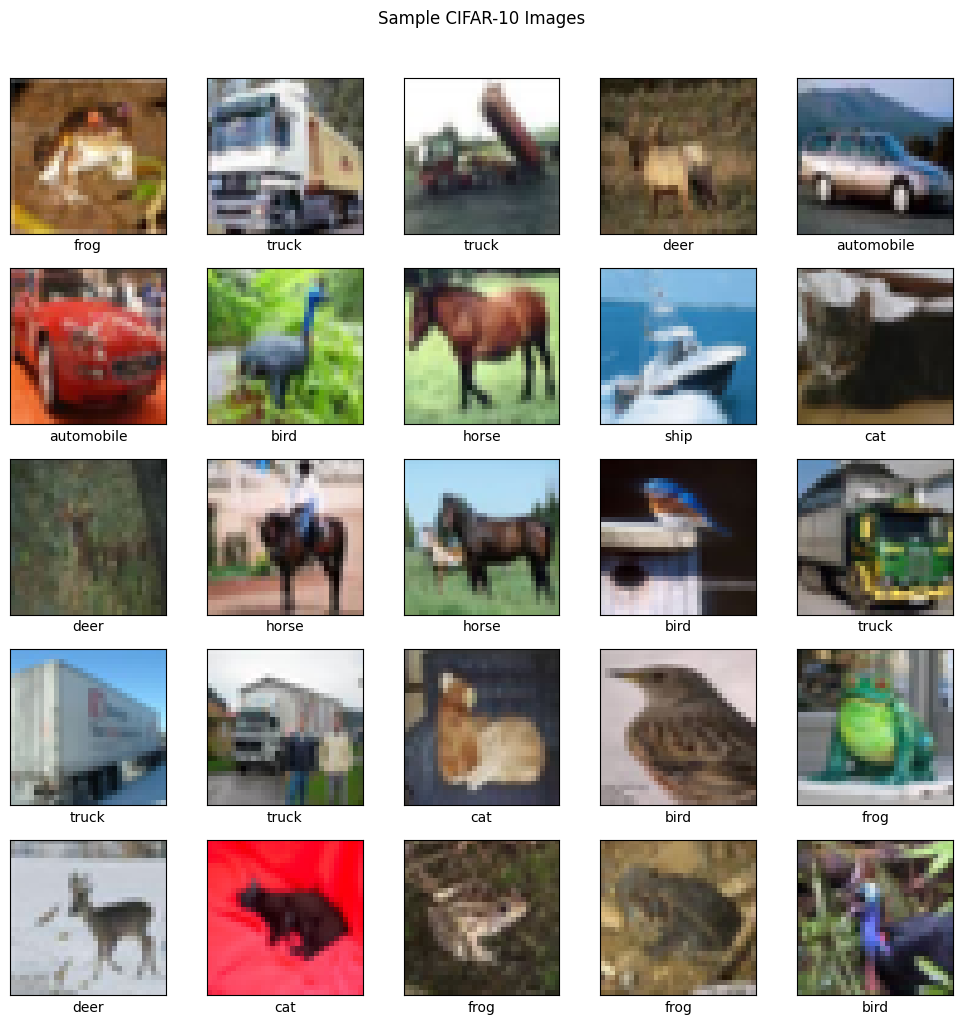

In [ ]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"x_train shape after normalization: {x_train.shape}")
print(f"y_train shape after one-hot encoding: {y_train.shape}")

# Display sample images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    # The CIFAR-10 labels are integers, but we converted to one-hot for training.
    # To display, we convert back to integer index.
    plt.xlabel(class_names[np.argmax(y_train[i])])
plt.suptitle('Sample CIFAR-10 Images', y=1.02)
plt.tight_layout()
plt.show()

### STEP 4: CNN Model Architecture Function

This step defines a function `build_cnn_model()` that constructs a Convolutional Neural Network (CNN) using Keras's Sequential API. The architecture includes `Conv2D` layers for feature extraction, `MaxPooling` layers for downsampling, a `Flatten` layer to convert 2D feature maps into a 1D vector, and `Dense` layers for classification. The model is compiled with the Adam optimizer, categorical cross-entropy loss, and accuracy as a metric.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

def build_cnn_model():
    model = Sequential([
        # First Conv2D layer
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
        MaxPooling2D((2, 2)),

        # Second Conv2D layer
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Flatten the output to feed into Dense layers
        Flatten(),

        # Dense layers
        Dense(128, activation='relu'),
        Dense(10, activation='softmax') # Output layer for 10 classes
    ])

    # Compile the model
    model.compile(optimizer=Adam(),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Build and display the model summary
model = build_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

### STEP 5: Train CNN Model

In this step, the defined CNN model is trained using the preprocessed CIFAR-10 training data. A portion of the training data (20%) is used for validation during training to monitor performance on unseen data. The model is trained for 10 epochs with a batch size of 64. The training history (loss and accuracy for both training and validation sets) is stored for later visualization.

In [ ]:
# Train the model
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2) # Use 20% of training data for validation

print("Model training complete.")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 103ms/step - accuracy: 0.4734 - loss: 1.4743 - val_accuracy: 0.5713 - val_loss: 1.2170
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6152 - loss: 1.1013 - val_accuracy: 0.6263 - val_loss: 1.0637
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.6654 - loss: 0.9583 - val_accuracy: 0.6552 - val_loss: 0.9942
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.6992 - loss: 0.8624 - val_accuracy: 0.6675 - val_loss: 0.9545
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.7257 - loss: 0.7841 - val_accuracy: 0.6782 - val_loss: 0.9258
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7520 - loss: 0.7130 - val_accuracy: 0.6811 - val_loss: 0.9425
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.7737 - loss: 0.6496 - val_accuracy: 0.6777 - val_loss: 0.9770
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.7946 - loss: 0.593

### STEP 6: Evaluate Model

After training, the model's performance is evaluated on the entirely unseen test dataset. This step assesses how well the model generalizes to new data. The test loss and test accuracy are calculated and printed to provide a final measure of the model's effectiveness.

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 - 9s - 29ms/step - accuracy: 0.6876 - loss: 1.0380

Test Loss: 1.0380
Test Accuracy: 0.6876


### STEP 7: Training Visualization

This step visualizes the training process by plotting the training and validation accuracy, as well as the training and validation loss over the epochs. These plots help in understanding the model's learning behavior, identifying overfitting or underfitting, and checking for convergence.

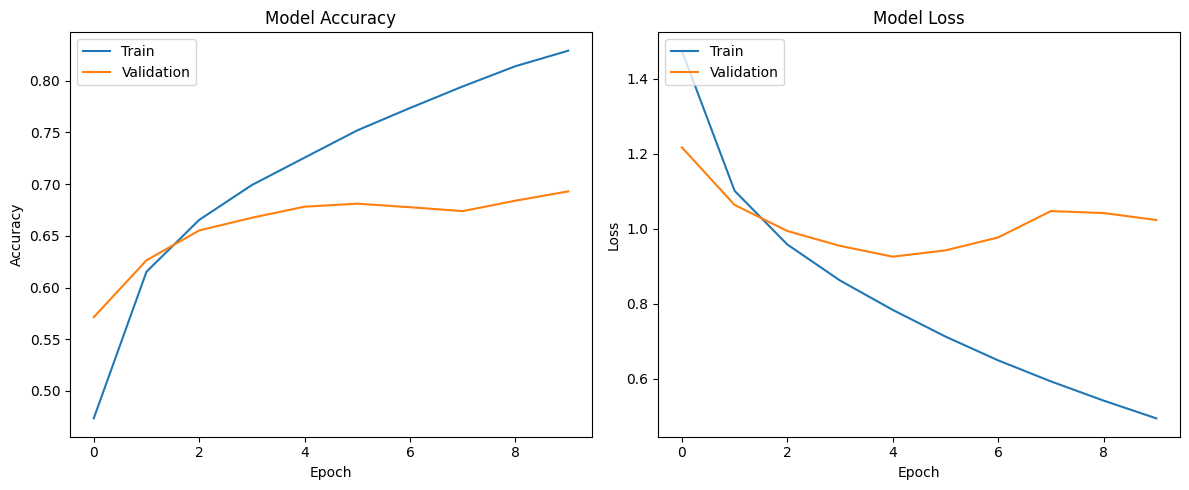

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### STEP 8: Feature Map Visualization

This is an important step to understand what the first convolutional layer of the CNN is learning. We take a sample image from the CIFAR-10 dataset, pass it through the first `Conv2D` layer, and then extract and visualize the feature maps (outputs of individual filters). This shows how different filters detect various patterns, edges, or textures in the input image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


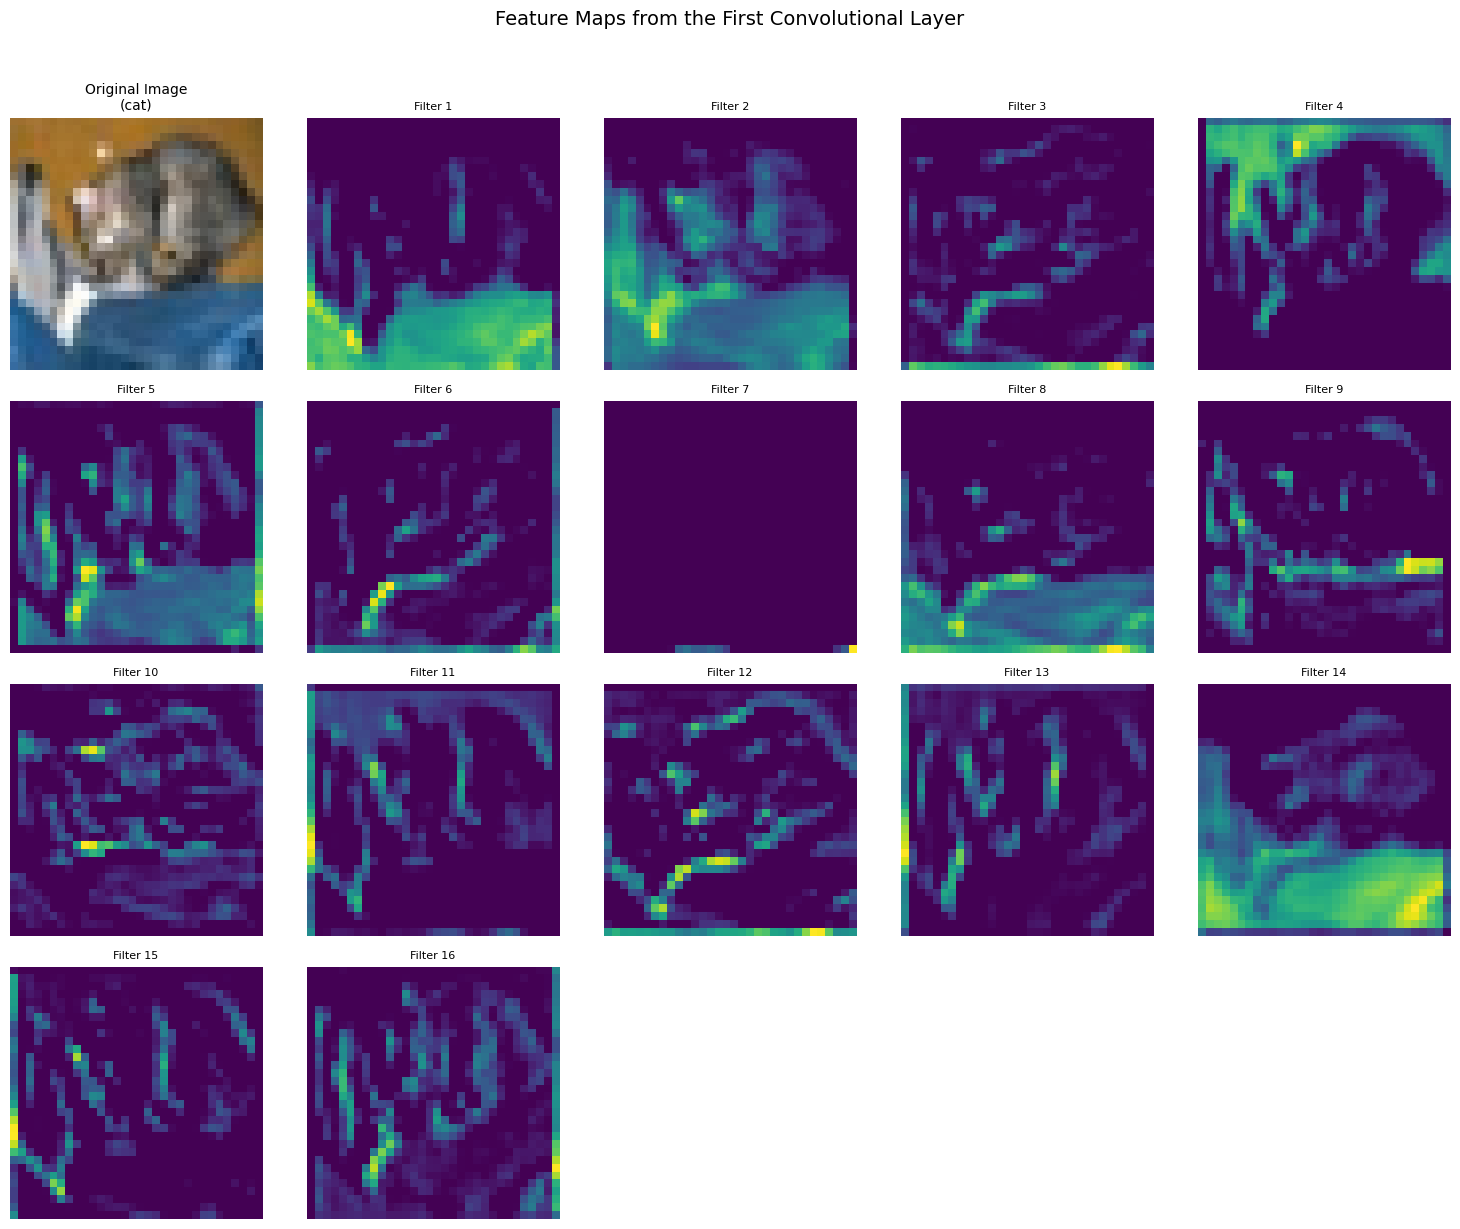

In [ ]:
from tensorflow.keras.models import Model

# Select a sample image from the test set
sample_image = x_test[0]
sample_image_label = np.argmax(y_test[0])

# Reshape the image to add a batch dimension (1, 32, 32, 3)
sample_image_batch = np.expand_dims(sample_image, axis=0)

# Create a model that outputs the activation of the first Conv2D layer
# The first Conv2D layer is `model.layers[0]`
feature_map_model = Model(inputs=model.inputs, outputs=model.layers[0].output)

# Get the feature maps for the sample image
feature_maps = feature_map_model.predict(sample_image_batch)

# Number of filters in the first Conv2D layer (32 in this case)
num_filters = feature_maps.shape[-1]

# Calculate dynamic subplot grid
num_fm_to_display = min(num_filters, 16) # Display up to 16 feature maps
total_plots_count = 1 + num_fm_to_display # 1 for original image + feature maps
num_cols = 5 # Fixed number of columns for visualization
num_rows = (total_plots_count + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 3, num_rows * 3)) # Adjust figure size dynamically

# Visualize the original image
plt.subplot(num_rows, num_cols, 1)
plt.imshow(sample_image)
plt.title(f"Original Image\n({class_names[sample_image_label]})", fontsize=10)
plt.axis('off')

# Visualize a subset of feature maps
for i in range(num_fm_to_display):
    plt.subplot(num_rows, num_cols, i + 2)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis') # Use a colormap for single channel
    plt.title(f'Filter {i+1}', fontsize=8)
    plt.axis('off')

plt.suptitle('Feature Maps from the First Convolutional Layer', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()